In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.express as px


In [3]:
# --- Load datasets ---
data_dir = "./data"

info = pd.read_csv(data_dir + "/amcdata_agreement_info_V2.csv",encoding='cp1252')
vercom = pd.read_csv(data_dir + "/amcdata_vercom_V2.csv")
weapons = pd.read_csv(data_dir + "/amcdata_weapons_facilities_V2.csv")

## Variables - Dictionary

### Agreement_Info

In [4]:

info_cols = ['agreement_id', 'year', 'agreement_profile_title',     
             'laterality', 'adoption_date', 'entry_into_force_date', 
             
             'nr_states_parties_total', 'nr_signatory_states', 
             'nr_states_parties_acceptance', 'nr_states_parties_succession',
             'nr_states_parties_approval', 'nr_states_parties_ratification', 'nr_states_parties_accession', 
             'states_parties_total',
             
             'status', 'state_withdrawal_nr', 'state_withdrawal',
             'weapons_items_topic', 'weapons_items',
             'consultation_mechanism',
             'demonstrated_compliance_mechanism', 'demonstrated_compliance_mechanism_nr',
             'verified_compliance_mechanism', 'verified_compliance_mechanism_nr',
             ]

info_sub = info[info_cols]

In [5]:
print("Total number of agreements: ", len(info), "\n")
print("Years:", info.year.min(), "-", info.year.max(), "\n")
print("*"*50)
print("""\nLaterality distribution: \n0.Unilateral statement or declaration\n1.Bilateral agreement, two states party to the agreement\n2.Multilateral agreements, three or more states party to the agreement\n""")
print(info.laterality.value_counts(), "\n")


Total number of agreements:  128 

Years: 1817 - 2021 

**************************************************

Laterality distribution: 
0.Unilateral statement or declaration
1.Bilateral agreement, two states party to the agreement
2.Multilateral agreements, three or more states party to the agreement

laterality
2    74
1    54
Name: count, dtype: int64 



In [6]:
print("""Status: Status of the agreement as of Decemebr 2023
0.In force
1.Formally terminated
2.Formally expired
3.Obsolete
4.Never entered into force
5.Yet to enter into force\n""")

print(info.status.value_counts())
print("*"*50, '\n')

print("""consultation_mechanism, demonstrated_compliance
_mechanism and verified_compliance_mechanism are flags - 1: presence, 0: absence \n""")
print("""demonstrated_compliance
_mechanism_nr, verified_compliance_mechanism_nr = number of said mechanisms established under that agreement\n""")

print("""-`nr_signatory_states` - Number of signatories
- `nr_states_parties_total` - Total state parties
- `nr_states_parties_ratification` - Ratified parties
- `nr_states_parties_accession` - Acceded parties""")


Status: Status of the agreement as of Decemebr 2023
0.In force
1.Formally terminated
2.Formally expired
3.Obsolete
4.Never entered into force
5.Yet to enter into force

status
0    79
2    13
6    12
4     8
1     8
3     6
5     2
Name: count, dtype: int64
************************************************** 

consultation_mechanism, demonstrated_compliance
_mechanism and verified_compliance_mechanism are flags - 1: presence, 0: absence 

demonstrated_compliance
_mechanism_nr, verified_compliance_mechanism_nr = number of said mechanisms established under that agreement

-`nr_signatory_states` - Number of signatories
- `nr_states_parties_total` - Total state parties
- `nr_states_parties_ratification` - Ratified parties
- `nr_states_parties_accession` - Acceded parties


In [7]:
print("""State Withdrawal: States having formally withdrawn from an agreement in
force as of December 2023 (date of formal withdrawal in
parenthisis) \n\n""", info.state_withdrawal.value_counts())

State Withdrawal: States having formally withdrawn from an agreement in
force as of December 2023 (date of formal withdrawal in
parenthisis) 

 state_withdrawal
The United States(2002-06-13)                                        7
Japan(1934-12-29)                                                    1
People's Democratic Republic of Korea(2003-01-11)                    1
Saudi Arabia(2024-01-05)                                             1
The United States(2019-08-02)                                        1
The Russian Federation(2023-11-07)                                   1
The Russian Federation(2021-12-18), The United States(2020-11-22)    1
The Russian Federation(2023-11-03)                                   1
Niger(2024-01-28), Mali(2024-01-28), Burkina Faso(2024-01-28)        1
The United States(2018-05-08)                                        1
Name: count, dtype: int64


In [8]:

print("""
Some agreements have the same adoption date. These usually represent multiple protocols following the same agreement. All of the above are multilateral and are in force (status 0). Not all agreements under one treaty (with the same adoption time), come into effect at the same time.

""")
info_sub[info.groupby('adoption_date')['adoption_date'].transform('count') > 1]



Some agreements have the same adoption date. These usually represent multiple protocols following the same agreement. All of the above are multilateral and are in force (status 0). Not all agreements under one treaty (with the same adoption time), come into effect at the same time.




,agreement_id,year,agreement_profile_title,laterality,adoption_date,entry_into_force_date,nr_states_parties_total,nr_signatory_states,nr_states_parties_acceptance,nr_states_parties_succession,...,status,state_withdrawal_nr,state_withdrawal,weapons_items_topic,weapons_items,consultation_mechanism,demonstrated_compliance_mechanism,demonstrated_compliance_mechanism_nr,verified_compliance_mechanism,verified_compliance_mechanism_nr
17,70,1967,Treaty of Tlatelolco,2,1967-02-14,1967-09-20,33.0,33.0,0.0,0.0,...,0,0.0,NaN,0,"Nuclear Weapons, Nuclear Materials",1.0,1.0,5.0,1.0,2.0
18,70001,1967,Protocol I to the Treaty of Tlatelolco,2,1967-02-14,1969-12-11,4.0,4.0,0.0,0.0,...,0,0.0,NaN,0,Nuclear Weapons,0.0,0.0,NaN,0.0,NaN
19,70002,1967,Protocol II to the Treaty of Tlatelolco,2,1967-02-14,1969-12-11,5.0,5.0,0.0,0.0,...,0,0.0,NaN,0,Nuclear Weapons,0.0,0.0,NaN,0.0,NaN
45,190,1981,Convention on Certain Conventional Weapons (CC...,2,1980-10-10,1983-12-02,126.0,50.0,5.0,8.0,...,0,0.0,NaN,3,NaN,0.0,1.0,1.0,0.0,NaN
46,190001,1981,Protocol I on Non-Detectable Fragments to the CCW,2,1980-10-10,1983-12-02,0.0,0.0,0.0,0.0,...,0,0.0,NaN,3,Weapons with the Primary Effect to Injure by N...,0.0,0.0,NaN,0.0,NaN
47,190002,1981,"Protocol II on Mines, BoobyTraps and Other Dev...",2,1980-10-10,1983-12-02,0.0,0.0,0.0,0.0,...,0,0.0,NaN,3,"Mines, Booby Traps, Other Devises, Mines Other...",0.0,0.0,NaN,0.0,NaN
48,190003,1981,Protocol III on Incediary Weapons to the CCW,2,1980-10-10,1983-12-02,0.0,0.0,0.0,0.0,...,0,0.0,NaN,3,"Incendiary Weapons, Air-Delivered Incendiary W...",0.0,0.0,NaN,0.0,NaN
55,210001,1986,Protocol I to the Treaty of Rarotonga,2,1986-08-08,1996-09-20,2.0,3.0,0.0,0.0,...,0,0.0,NaN,0,"Nuclear Explosive Devises, Fissile Material",0.0,0.0,NaN,0.0,NaN
56,210002,1986,Protocol II to the Treaty of Rarotonga,2,1986-08-08,1988-04-21,4.0,5.0,0.0,0.0,...,0,0.0,NaN,0,Nuclear Explosive Devises,0.0,0.0,NaN,0.0,NaN
57,210003,1986,Protocol III to the Treaty of Rarotonga,2,1986-08-08,1988-04-21,4.0,5.0,0.0,0.0,...,0,0.0,NaN,0,Nuclear Explosive Devises,0.0,0.0,NaN,0.0,NaN


In [9]:
## Other potentially relevant info

'obligations_weapons_specific', 'weapons_items_topic', 'weapons_items_nr', 
'obligations_location_specific', 'obligations_location', 'obligations_domain_specific', 'obligations_domain',
'obligations_facilites', 'obligations_facilities_nr', 'obligations_facilites_specified',

"""The general topic of weapon items regulated by
agreement:
0.Nuclear weapons
1.Biological weapons
2.Chemical weapons
3.Conventional weapons
4.General"""

info.weapons_items_topic.value_counts()

weapons_items_topic
0       66
3       33
4       11
2        4
1        2
2, 3     1
Name: count, dtype: int64

### VerCom

In [10]:
vercom_cols = ['agreement_id', 
               'verified_compliance_mechanism_type',
               'verified_compliance_mechanism_category', 'verified_compliance_mechanism_inspector_type',
               'verified_compliance_mechanism_inspector_type_established_body',
               'verified_compliance_mechanism_inspector_type_utlilized_body',
               'verified_compliance_mechanism_area_access',
               'verified_compliance_mechanism_facility_access',
               'verified_compliance_mechanism_item_access',
               'verified_compliance_mechanism_item_section_access',
               'verified_compliance_mechanism_area',
               'verified_compliance_mechanism_facility',
               'verified_compliance_mechanism_item',
               'verified_compliance_mechanism_item_section',
               'verified_compliance_mechanism_trigger_type',
               'verified_compliance_mechanism_agreement_trigger_cyclical']
vercom_sub = vercom[vercom_cols]   

In [11]:
print("Total number of rows: ", len(vercom), "\n")


Total number of rows:  99 



#### Types

In [12]:
print("""Type of verified compliance mechanism:
0.initiated compliance
1.Updated compliance
2.Challenged compliance
3.Completed compliance
4.Other
""")
print(vercom.verified_compliance_mechanism_type.value_counts())


Type of verified compliance mechanism:
0.initiated compliance
1.Updated compliance
2.Challenged compliance
3.Completed compliance
4.Other

verified_compliance_mechanism_type
1.0    46
3.0    20
2.0    13
0.0    10
4.0     1
Name: count, dtype: int64


In [13]:
print("""Category: Type of verified compliance mechanism
- Can also be a contributor to level of intrusiveness
0. NTMs
1. Display
2. Remote monitoring
3. In-person exhibition
4. In-person demonstration
5. In-person Inspection
6. In-person monitoring
7. Other
      """)
print(vercom.verified_compliance_mechanism_category.value_counts())

Category: Type of verified compliance mechanism
- Can also be a contributor to level of intrusiveness
0. NTMs
1. Display
2. Remote monitoring
3. In-person exhibition
4. In-person demonstration
5. In-person Inspection
6. In-person monitoring
7. Other
      
verified_compliance_mechanism_category
5    61
3    12
0    10
6     6
7     4
2     3
1     2
4     1
Name: count, dtype: int64


#### Triggers

In [14]:
print("*"*50)
print("""Type of mechanism trigger;
0.Agreement
1.State-party notification
2.State-party request
3.Circumstance
4.Agreement association
5.Other
      """)
print(vercom.verified_compliance_mechanism_trigger_type.value_counts())

print("*"*50)
print("""Type of agreement trigger:
0.One time
1.Oouta
2.Cyclical
3.Continous
      """)
print(vercom.verified_compliance_mechanism_agreement_trigger_type.value_counts())

print("*"*50)
print("Time in between cyclical verified compliance\n",vercom.verified_compliance_mechanism_agreement_trigger_cyclical.value_counts())

print("*"*50)
print("Agreement association triggering the mechanism", vercom.trigger_association.value_counts())

**************************************************
Type of mechanism trigger;
0.Agreement
1.State-party notification
2.State-party request
3.Circumstance
4.Agreement association
5.Other
      
verified_compliance_mechanism_trigger_type
0    41
1    29
2    11
5    11
4     6
7     1
Name: count, dtype: int64
**************************************************
Type of agreement trigger:
0.One time
1.Oouta
2.Cyclical
3.Continous
      
verified_compliance_mechanism_agreement_trigger_type
0.0    24
3.0    19
2.0    13
1.0     7
4.0     1
Name: count, dtype: int64
**************************************************
Time in between cyclical verified compliance
 Series([], Name: count, dtype: int64)
**************************************************
Agreement association triggering the mechanism trigger_association
United Nations Security Council                                 1
The Consultative Committee                                      1
The Commission                                   

#### Access and Intrusiveness

Access Types
      
1. Area access
The territories, areas, or locations accessible to in-person/remote control.
2. Facility access
The facilities/type of facilities accessible to in-person/remote control.
3. Item access
The objects, structures, and information accessible to in-person/remote control.

In [15]:
print("""Area Access, Facility Access, Item Access, Item Section Access: Binaries - 0/1
      """)
print("""Details of access provisions:
      verified_compliance_mechanism_area, 
      verified_compliance_mechanism_facility, 
      verified_compliance_mechanism_item, verified_compliance_mechanism_item_section
      """)

print("*"*50)


print("""More Access Variables:
      Development Access: 0
      Testing Access: 4
      Production Access: 1
      Acquisition Access: 0
      Possession Access: 50
      Stationing Access: 0
      Use Access: 9
      Transfer Access: 0
""")



Area Access, Facility Access, Item Access, Item Section Access: Binaries - 0/1
      
Details of access provisions:
      verified_compliance_mechanism_area, 
      verified_compliance_mechanism_facility, 
      verified_compliance_mechanism_item, verified_compliance_mechanism_item_section
      
**************************************************
More Access Variables:
      Development Access: 0
      Testing Access: 4
      Production Access: 1
      Acquisition Access: 0
      Possession Access: 50
      Stationing Access: 0
      Use Access: 9
      Transfer Access: 0



In [16]:
print("Area Access Depth - Types of Areas\n")
print(vercom.verified_compliance_mechanism_area.value_counts())

Area Access Depth - Types of Areas

verified_compliance_mechanism_area
Facilities within the territory of the other party and basing countries [Article XI.2].                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  7
Inspectors have access to locations of all underground nuclear explosions conducted outside national nuclear test sites for any given explosion of the other party [Protocol. III. 1].                                                

In [17]:
print("Facility Access Depth - Types of Facilities\n")
print(vercom.verified_compliance_mechanism_facility.value_counts())

Facility Access Depth - Types of Facilities

verified_compliance_mechanism_facility
Facilities not specified                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  5
Within specified territory, inspectors have access to the site of the explosion and facilities and structures related to the conduct of the explosion along agreed routes [Protocol. VII. 2].                           

In [18]:
print("Item Access Depth - Types of Items\n")
print(vercom.verified_compliance_mechanism_item.value_counts())

Item Access Depth - Types of Items

verified_compliance_mechanism_item
Items not specified                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [19]:
print("Item Section Access Depth - Types of Item Sections\n")
print(vercom.verified_compliance_mechanism_item_section.value_counts())

Item Section Access Depth - Types of Item Sections

verified_compliance_mechanism_item_section
Sections not specified                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

#### Inspection

In [20]:

print("""Inspector Type:
      
The type of inspector;
0.Party on party
1.Agreement-established association
2.Utilized association
3.Other
      """)
print(vercom.verified_compliance_mechanism_inspector_type.value_counts())

print("*"*50)

print("Established Association\n")
print(vercom.verified_compliance_mechanism_inspector_type_established_body.value_counts())
print("*"*50)

print("Utilised Association\n")
print(vercom.verified_compliance_mechanism_inspector_type_utlilized_body
.value_counts())




Inspector Type:

The type of inspector;
0.Party on party
1.Agreement-established association
2.Utilized association
3.Other
      
verified_compliance_mechanism_inspector_type
0    78
1    11
2    10
Name: count, dtype: int64
**************************************************
Established Association

verified_compliance_mechanism_inspector_type_established_body
Inspectors and inspection assistants designated by the Technical Secretariat                                                          4
Fact Finding Mission                                                                                                                  2
The Organisation                                                                                                                      2
The General Secretary(and te technical personnel)designated by the Council                                                            1
The Brazilian-Argentine Agency for Accounting and Control of Nuclear Materials (hereinafter 

### Weapons

In [21]:
weapons_cols = ['agreement_id',"item", 'item_type', 'summary_category']
weapons_sub = weapons[weapons_cols]

In [22]:
print("Total number of rows: ", len(vercom), "\n")

Total number of rows:  99 



In [23]:
print(weapons.item.value_counts())


item
Summary Category A (Nuclear Weapons)              30
Nuclear Weapons                                   17
Summary Category B (Conventional Weapons Land)    14
Weapons General                                    9
Summary Category D (Conventional Weapons Air)      8
                                                  ..
Chemical weapons storage facilities                1
Laser                                              1
Personel/equipment of armed forces                 1
Space Launch Vehicles                              1
Combat Aircraft                                    1
Name: count, Length: 240, dtype: int64


In [24]:
print("""Type of item:
0.Weapons & ammunition
1.Facility
2.Materials/components
3.Other
""")
print(weapons.item_type.value_counts())

print("*"*50)

print("""0.The item is not a fictional summary category added by
AMC Data
1.The item is a fictional summary category added by AMC
Data
""")
print(weapons.summary_category.value_counts())



Type of item:
0.Weapons & ammunition
1.Facility
2.Materials/components
3.Other

item_type
1.0    308
0.0     61
2.0     29
3.0     28
4.0      5
Name: count, dtype: int64
**************************************************
0.The item is not a fictional summary category added by
AMC Data
1.The item is a fictional summary category added by AMC
Data

summary_category
0.0    266
1.0     83
Name: count, dtype: int64


#### Bans and Restrictions

1. Bans:
- Development ban - 34
- Testing ban - 45 
- Acquisition Ban - 54
- Deployed possession Ban
- Use Ban
- Disposal Ban

2. Restrictions:
- Development restriction - 46
- Testing restriction
- Production restriction - 84
- Acquisition restriction
- General possession restriction
- Non-deployed possession restriction
- Deployed possession restriction
- Transfer restriction
- Station restriction
- Disposal restriction


## Distributions

1. How do access provisions differ with weapon type (in both info and weapons)
and agreement cat
9. consult + demcom + vercom dist (across weapons, lateralities, time?)




2. Inspector type + weapons dist
3. Inspector type + access dist
4. Inspecting org + access + weapons dist


5. Triggers (cyclic, challenge, agreement etc) + weapon type + access
6. Agreement failures (withdrawals)
7. Each access mech + laterality + signatories
8. Inspector type + signatories
10. Each access mech depth (qual) + signatories/laterality + weapon type (access - area, item might vary with type of weapon?)

11. Access intensity + laterality/signatories + weapon type (era *lower signatories early days? / duration, inspection, demcom/vercom/consult, laterality)
    
12. Nr of vercom/demcom can also be indicative of intensity


In [25]:
info_ver = info_sub.join(vercom_sub.set_index('agreement_id'), on='agreement_id', how='left')
info_weap = info_sub.join(weapons_sub.set_index('agreement_id'), on='agreement_id', how='left')


In [26]:


def dist(var2_cols, var2_map, weapon_map, df, weapon_col, 
                main_title, plt1_title, plt2_title, p1x, p1y, p2x, p2y):
    df['clean'] = df[weapon_col].map(weapon_map)

    counts = df.groupby('clean')[var2_cols].sum()

    counts = counts.rename(columns=var2_map)
    print(counts.values.sum())

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    plt.suptitle(main_title, fontsize=16)

    # --- (1) Counts: Weapon on X ---
    counts.plot(kind='bar', ax=axes[0])
    axes[0].set_title(plt1_title)
    axes[0].set_xlabel(p1x)
    axes[0].set_ylabel(p1y)
    axes[0].tick_params(axis='x', rotation=0)

    # --- (2) Counts: Access on X ---
    counts.T.plot(kind='bar', ax=axes[1])
    axes[1].set_title(plt2_title)
    axes[1].set_xlabel(p2x)
    axes[1].set_ylabel(p2y)
    axes[1].tick_params(axis='x', rotation=30)

    # --- Clean legends (avoid repetition) ---
    for ax in axes.flat:
        ax.legend().set_title("")

    plt.tight_layout()
    plt.savefig(f"plots/{main_title.replace(' ', '_')}.png")
    plt.show()
    


In [27]:
info_sub.groupby("weapons_items_topic").verified_compliance_mechanism.value_counts()

weapons_items_topic  verified_compliance_mechanism
0                    0.0                              45
                     1.0                              21
1                    0.0                               1
                     1.0                               1
2                    1.0                               2
                     0.0                               2
2, 3                 1.0                               1
3                    0.0                              28
                     1.0                               5
4                    0.0                               8
                     1.0                               3
Name: count, dtype: int64

120.0


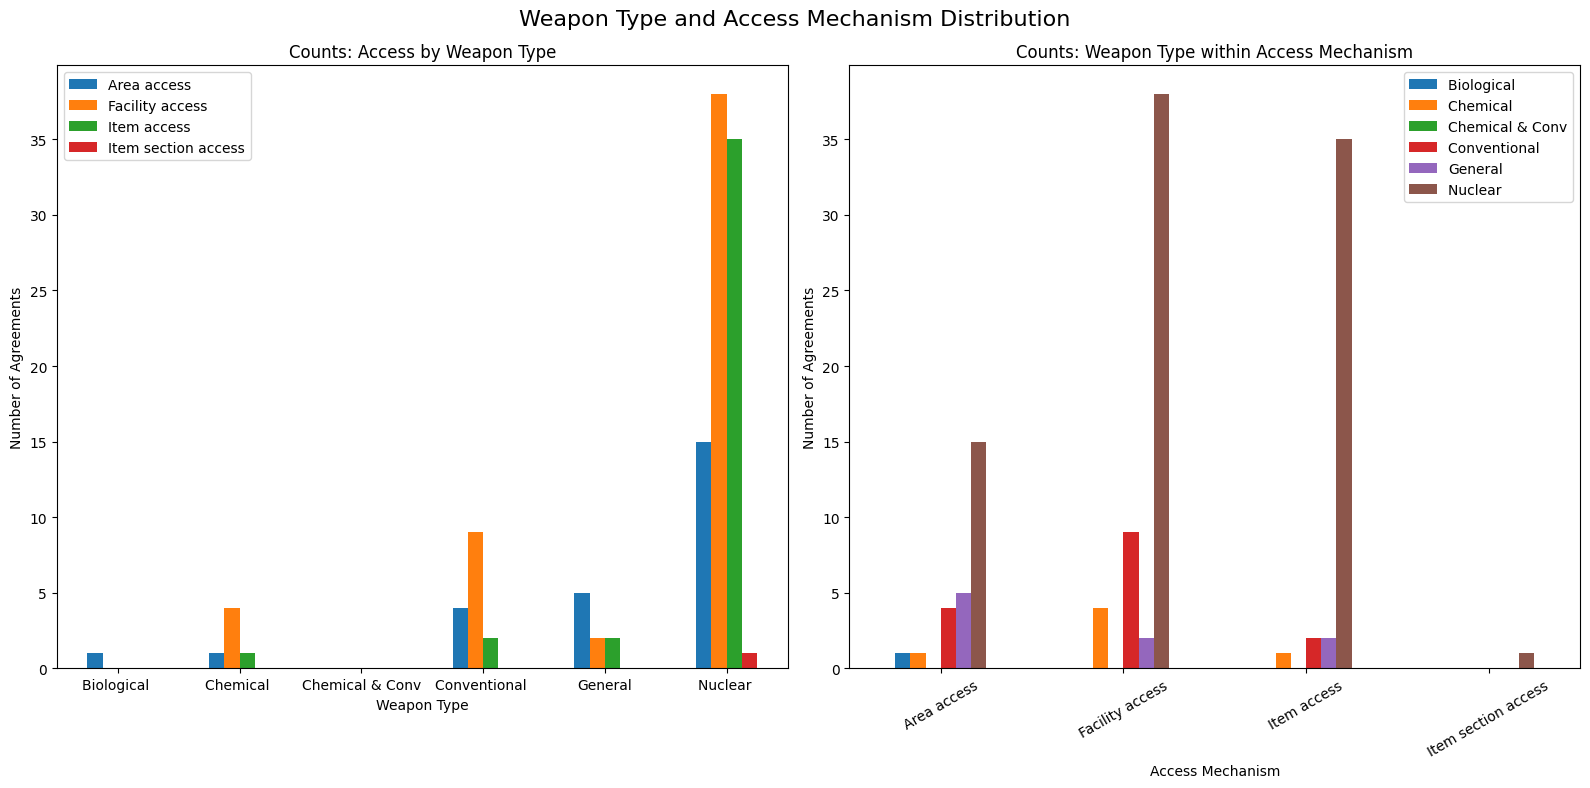

In [36]:
#Total values in the plots might be </> total agreements because not all agreements have any compliance mechanism, and some agreements have multiple mechanisms. 

main_title = "Weapon Type and Access Mechanism Distribution"
plt1_title = "Counts: Access by Weapon Type"
plt2_title = "Counts: Weapon Type within Access Mechanism"
p1x = "Weapon Type"
p1y = "Number of Agreements"
p2x = "Access Mechanism"
p2y = "Number of Agreements"
access_cols = [
    'verified_compliance_mechanism_area_access',
    'verified_compliance_mechanism_facility_access',
    'verified_compliance_mechanism_item_access',
    'verified_compliance_mechanism_item_section_access'
]

access_map = {
    'verified_compliance_mechanism_area_access': 'Area access',
    'verified_compliance_mechanism_facility_access': 'Facility access',
    'verified_compliance_mechanism_item_access': 'Item access',
    'verified_compliance_mechanism_item_section_access': 'Item section access'
}


weapon_map = {
    '0': 'Nuclear ',
    '1': 'Biological ',
    '2': 'Chemical ',
    '3': 'Conventional ',
    '2, 3': 'Chemical & Conv',
    '4': 'General'
}

dist(access_cols, access_map, weapon_map, info_ver, 'weapons_items_topic', 
                main_title, plt1_title, plt2_title, p1x, p1y, p2x, p2y)

155.0


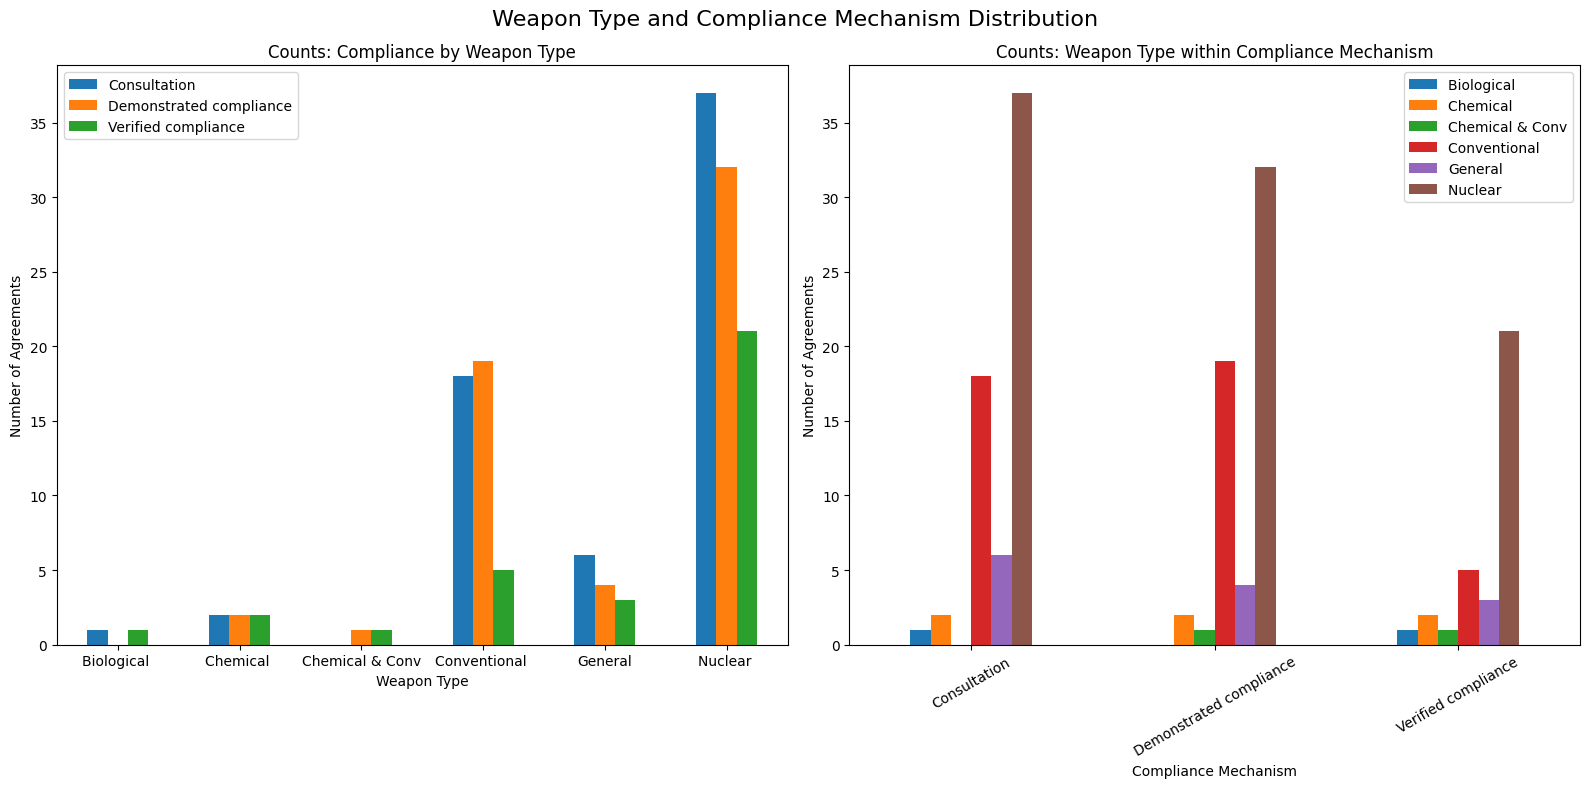

In [37]:
main_title = "Weapon Type and Compliance Mechanism Distribution"
plt1_title = "Counts: Compliance by Weapon Type"
plt2_title = "Counts: Weapon Type within Compliance Mechanism"
p1x = "Weapon Type"
p1y = "Number of Agreements"
p2x = "Compliance Mechanism"
p2y = "Number of Agreements"


mech_cols = [
    'consultation_mechanism',
    'demonstrated_compliance_mechanism',
    'verified_compliance_mechanism',
]

mech_map = {
    'consultation_mechanism': 'Consultation',
    'demonstrated_compliance_mechanism': 'Demonstrated compliance',
    'verified_compliance_mechanism': 'Verified compliance'
}


weapon_map = {
    '0': 'Nuclear ',
    '1': 'Biological ',
    '2': 'Chemical ',
    '3': 'Conventional ',
    '2, 3': 'Chemical & Conv',
    '4': 'General'
}


dist(mech_cols, mech_map, weapon_map, info_sub, 'weapons_items_topic', 
                main_title, plt1_title, plt2_title, p1x, p1y, p2x, p2y)

157.0


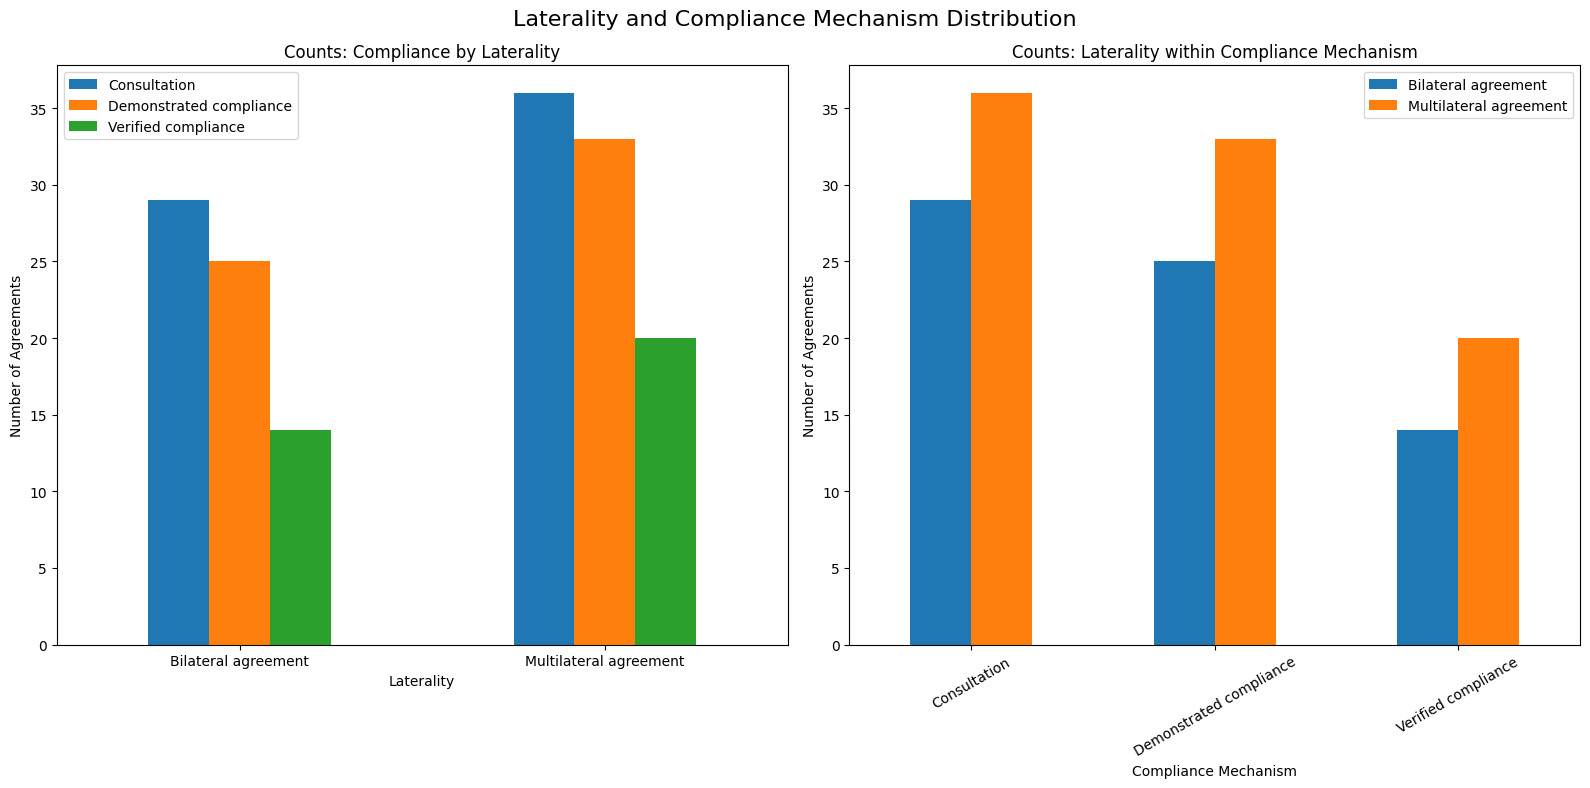

In [38]:
main_title = "Laterality and Compliance Mechanism Distribution"
plt1_title = "Counts: Compliance by Laterality"
plt2_title = "Counts: Laterality within Compliance Mechanism"
p1x = "Laterality"
p1y = "Number of Agreements"
p2x = "Compliance Mechanism"
p2y = "Number of Agreements"

lat_map = {
    1: 'Bilateral agreement',
    2: 'Multilateral agreement'
}
dist(mech_cols, mech_map, lat_map, info_sub, 'laterality', 
                main_title, plt1_title, plt2_title, p1x, p1y, p2x, p2y)

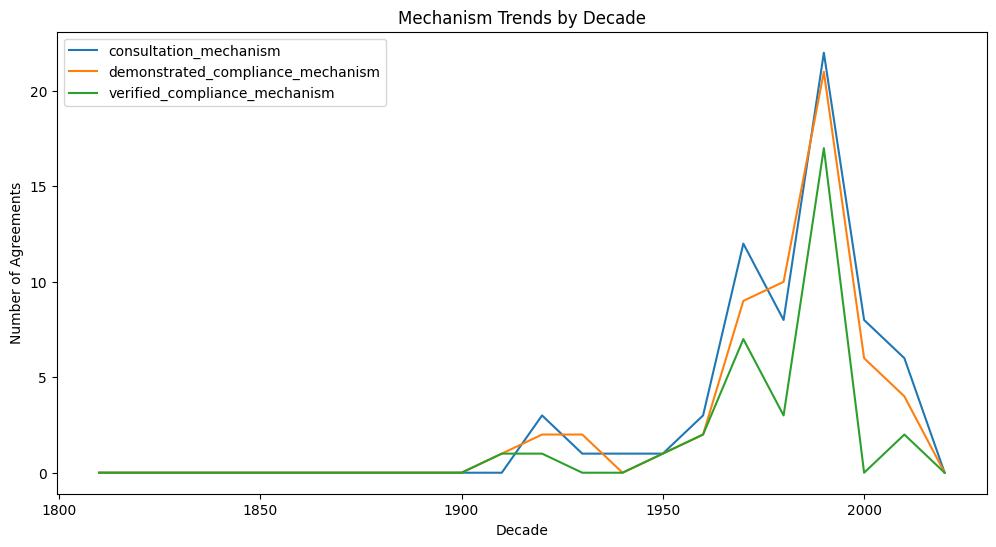

In [39]:
mech_cols = [
    'consultation_mechanism',
    'demonstrated_compliance_mechanism',
    'verified_compliance_mechanism',
]

info_sub = info_sub.copy()

# ensure numeric
info_sub['year'] = pd.to_numeric(info_sub['year'], errors='coerce')
info_sub = info_sub.dropna(subset=['year'])
info_sub['decade'] = (info_sub['year'] // 10) * 10

decade_counts = info_sub.groupby('decade')[mech_cols].sum()
decade_counts.plot(figsize=(12,6))

plt.title("Mechanism Trends by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Agreements")
plt.savefig("plots/mechanism_trends_by_decade.png")
plt.show()


126.0


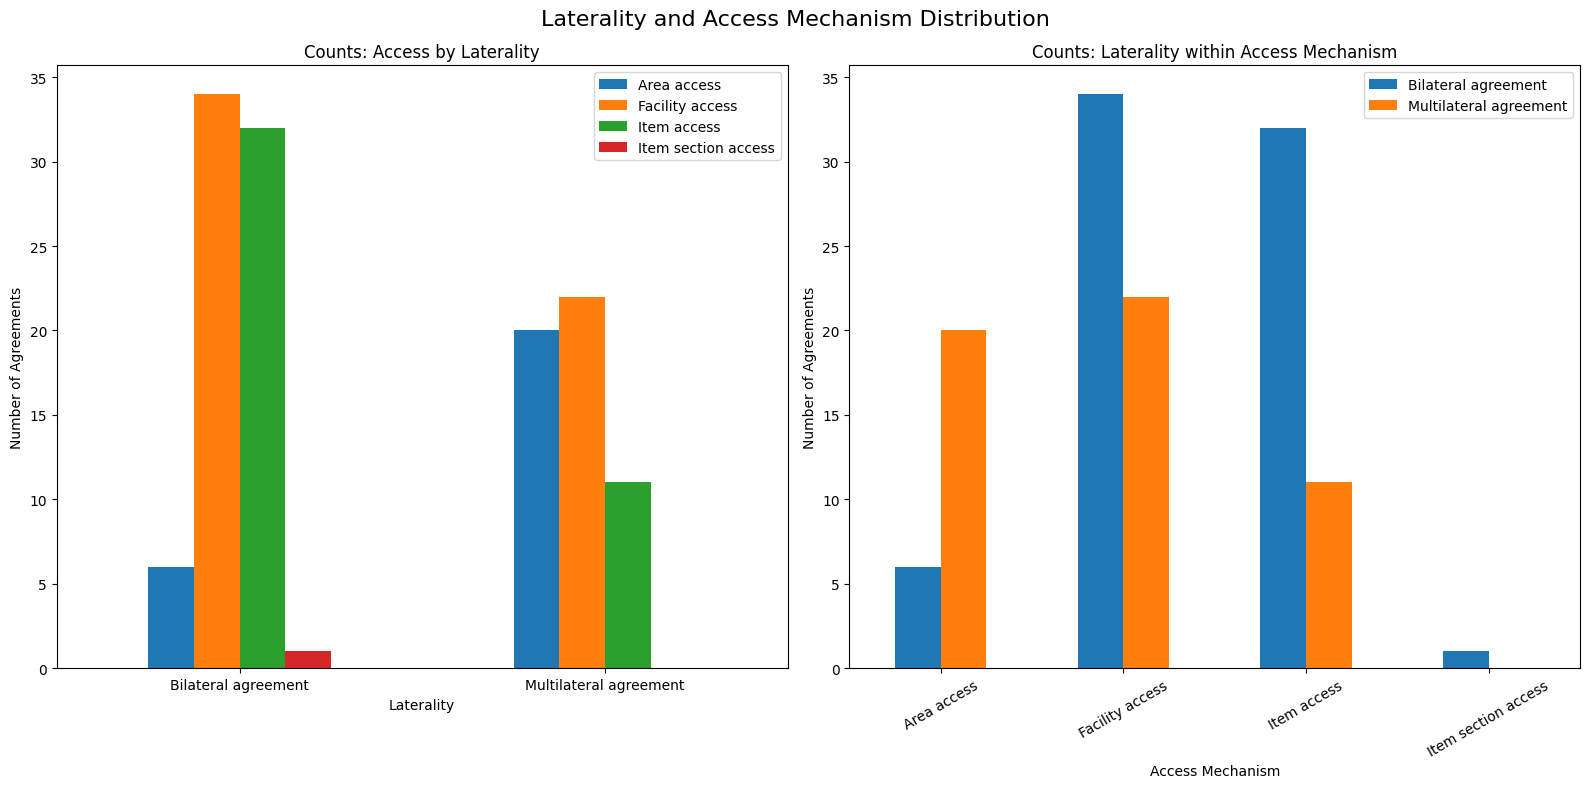

In [40]:
main_title = "Laterality and Access Mechanism Distribution"
plt1_title = "Counts: Access by Laterality"
plt2_title = "Counts: Laterality within Access Mechanism"
p1x = "Laterality"
p1y = "Number of Agreements"
p2x = "Access Mechanism"
p2y = "Number of Agreements"

lat_map = {
    1: 'Bilateral agreement',
    2: 'Multilateral agreement'
}
dist(access_cols, access_map, lat_map, info_ver, 'laterality', 
                main_title, plt1_title, plt2_title, p1x, p1y, p2x, p2y)

In [41]:
df = info_ver.copy()

df = df.drop_duplicates('agreement_id').copy()
df['decade'] = (df['year'] // 10) * 10
nice_names = {
    'verified_compliance_mechanism_area_access': 'Area access',
    'verified_compliance_mechanism_facility_access': 'Facility access',
    'verified_compliance_mechanism_item_access': 'Item access',
    'verified_compliance_mechanism_item_section_access': 'Item section access',
    'consultation_mechanism': 'Consultation Flag',
    'demonstrated_compliance_mechanism_nr': 'DemCom Count',
    'verified_compliance_mechanism_nr': 'VerCom Count',
    'demonstrated_compliance_mechanism': 'DemCom',
    'verified_compliance_mechanism': 'VerCom'

}

df_renamed = df.rename(columns=nice_names)

hover_cols = ['year', 'agreement_profile_title','laterality', 'agreement_id'] + ['Consultation Flag', 'DemCom Count', 'VerCom Count'] + ['Area access', 'Facility access', 'Item access', 'Item section access']

title = "Total State Parties by Decade"

fig = px.scatter(
    df_renamed,
    x='decade',
    y='nr_states_parties_total',
    hover_data=hover_cols ,
    title = title
)
fig.write_image(f"plots/{title.replace(' ', '_')}.png")
fig.update_xaxes(title_text='Decade')
fig.update_yaxes(title_text='Total State Parties')

fig.show()

C:\Users\18055\AppData\Local\Temp\ipykernel_5896\2502751472.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_title("")


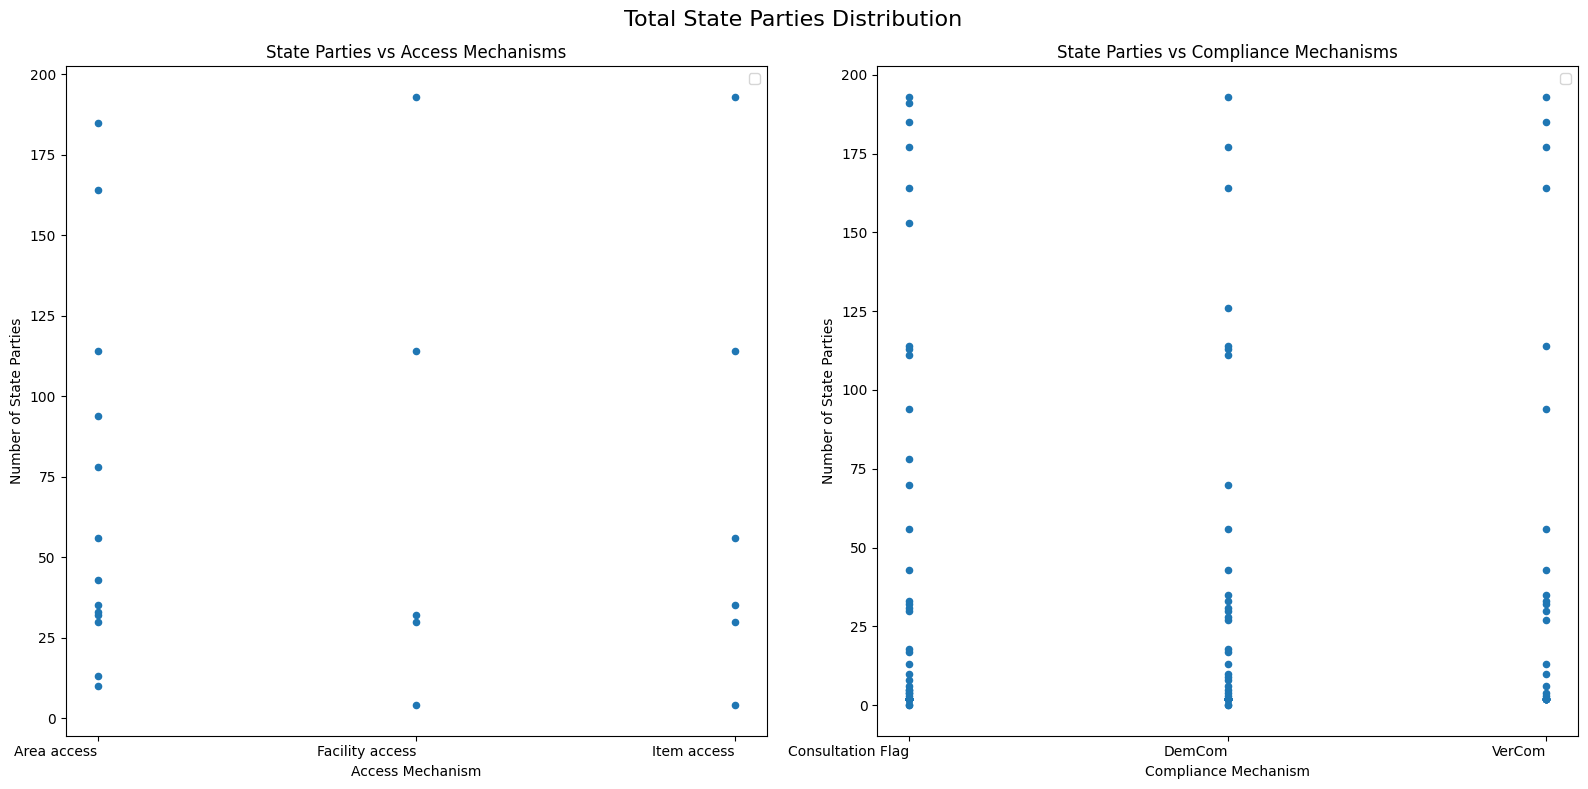

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
title = 'Total State Parties Distribution'
plt.suptitle(title, fontsize=16)

# --- (1)  ---
access_long = df.melt(
    id_vars=['agreement_id', 'nr_states_parties_total'],
    value_vars=access_cols,
    var_name='mechanism',
    value_name='has_mech'
)

# keep only where mechanism exists
access_long = access_long[access_long['has_mech'] == 1]


access_long.plot(kind='scatter', x='mechanism', y='nr_states_parties_total', ax=axes[0])

axes[0].set_title('State Parties vs Access Mechanisms')
axes[0].set_xlabel('Access Mechanism')
axes[0].set_ylabel('Number of State Parties')
axes[0].tick_params(axis='x', rotation=0)

labels0 = [nice_names.get(label.get_text(), label.get_text()) for label in axes[0].get_xticklabels()]
axes[0].set_xticks(axes[0].get_xticks()) # Fixes a Matplotlib warning
axes[0].set_xticklabels(labels0, rotation=0, ha='right')


# # --- (2)  ---

comp_long = df.melt(
    id_vars=['agreement_id', 'nr_states_parties_total'],
    value_vars=mech_cols,
    var_name='mechanism',
    value_name='has_mech'
)

comp_long = comp_long[comp_long['has_mech'] == 1]

comp_long.plot(kind='scatter', x='mechanism', y='nr_states_parties_total', ax=axes[1])

axes[1].set_title('State Parties vs Compliance Mechanisms')
axes[1].set_xlabel('Compliance Mechanism')
axes[1].set_ylabel('Number of State Parties')
axes[1].tick_params(axis='x', rotation=0)

labels1 = [nice_names.get(label.get_text(), label.get_text()) for label in axes[1].get_xticklabels()]
axes[1].set_xticks(axes[1].get_xticks()) # Fixes a Matplotlib warning
axes[1].set_xticklabels(labels1, rotation=0, ha='right')


# --- Clean legends (avoid repetition) ---
for ax in axes.flat:
    ax.legend().set_title("")

plt.tight_layout()
plt.savefig(f"plots/{title.replace(' ', '_')}.png")
plt.show()

## Questions/Directions
Confounders:
